Environment Setup & Data Ingestion

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# Configuration & Aesthetic Settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['figure.dpi'] = 120

# Color Palettes
PALETTE_CLASS = {0: "#2B5C8F", 1: "#D9383A", "0": "#2B5C8F", "1": "#D9383A"}  # 0: Legitimate (Navy), 1: Fraud (Crimson)
PALETTE_MULTI = ["#2B5C8F", "#4A90E2", "#F39C12", "#E74C3C", "#8E44AD", "#16A085", "#2C3E50"]

# Load Dataset
df = pd.read_csv("dataset.csv")
print(f"✅ Dataset successfully loaded: {df.shape[0]:,} rows × {df.shape[1]} columns.")
df.head()

✅ Dataset successfully loaded: 20,000 rows × 26 columns.


,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,...,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
0,1,42.86,Restaurants,Visa,OTP,Online,Android Phone,False,13.54,2,...,False,False,0,0.1,18,3,False,42.3,0,0
1,2,4.75,Online Retail,Mastercard,3D Secure,Online,Android Phone,False,0.71,2,...,False,False,0,25.8,12,4,False,28.3,0,0
2,3,77.18,Groceries,Mastercard,3D Secure,Online,Mac,False,0.35,5,...,False,True,0,42.3,5,0,False,24.7,1,0
3,4,1.69,Streaming,Visa,No Authentication,POS,Android Phone,False,3.42,6,...,False,False,0,28.9,22,6,False,56.2,1,0
4,5,261.68,Travel,Visa,3D Secure,In-App,iPhone,False,2.43,2,...,False,False,0,3.9,2,4,False,32.7,0,0


Dataset Architecture & Data Integrity Checks

In [26]:
# Dataset Schema & Data Types
schema_df = pd.DataFrame({
    'Column Name': df.columns,
    'Data Type': df.dtypes.values,
    'Null Count': df.isnull().sum().values,
    'Null %': (df.isnull().sum().values / len(df)) * 100,
    'Unique Values': df.nunique().values,
    'Sample Value': [df[col].iloc[0] for col in df.columns]
})
display(schema_df)
duplicates_count = df.duplicated().sum()
print(f"\nDuplicate Records: {duplicates_count} (No duplicate transactions detected)")

,Column Name,Data Type,Null Count,Null %,Unique Values,Sample Value
0,transaction_id,int64,0,0.0,20000,1
1,amount_usd,float64,0,0.0,12782,42.86
2,merchant_category,object,0,0.0,12,Restaurants
3,card_type,object,0,0.0,5,Visa
4,auth_method,object,0,0.0,5,OTP
5,channel,object,0,0.0,5,Online
6,device_type,object,0,0.0,8,Android Phone
7,is_foreign_transaction,bool,0,0.0,2,False
8,hours_since_last_txn,float64,0,0.0,3296,13.54
9,txn_count_last_24h,int64,0,0.0,13,2



Duplicate Records: 0 (No duplicate transactions detected)


In [27]:
# Numerical Features Summary Statistics
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_stats = df[num_cols].describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
num_stats['skewness'] = df[num_cols].skew()
num_stats['kurtosis'] = df[num_cols].kurt()
display(num_stats.round(2))

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
transaction_id,20000.0,10000.50,5773.65,1.00,5000.75,10000.50,15000.25,20000.00,0.00,-1.20
amount_usd,20000.0,132.42,256.96,1.00,26.24,57.51,131.75,6872.69,7.21,87.55
hours_since_last_txn,20000.0,8.95,8.84,0.01,2.59,6.21,12.43,87.05,1.89,5.05
txn_count_last_24h,20000.0,3.19,1.78,0.00,2.00,3.00,4.00,12.00,0.55,0.24
distance_from_home_km,20000.0,22.14,22.12,0.00,6.34,15.50,30.82,216.19,2.03,6.24
card_age_months,20000.0,46.94,6.77,22.00,42.00,47.00,51.00,74.00,0.12,-0.01
customer_age,20000.0,49.67,18.49,18.00,34.00,50.00,66.00,81.00,-0.01,-1.19
account_balance_usd,20000.0,3316.66,4350.72,52.05,1019.14,2007.68,3944.12,127125.86,5.63,70.30
cvv_retry_count,20000.0,0.18,0.42,0.00,0.00,0.00,0.00,3.00,2.29,5.06
velocity_score,20000.0,19.81,12.37,0.00,10.70,18.80,27.60,74.40,0.54,0.17


In [28]:
# Categorical & Boolean Features Overview
cat_bool_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
cat_overview = []
for col in cat_bool_cols:
    top_val = df[col].value_counts().index[0]
    top_freq = df[col].value_counts().iloc[0]
    cat_overview.append({
        'Feature': col,
        'Dtype': str(df[col].dtype),
        'Cardinality': df[col].nunique(),
        'Top Value': str(top_val),
        'Top Value Count': top_freq,
        'Top Value %': round((top_freq / len(df)) * 100, 2)
    })
display(pd.DataFrame(cat_overview))

,Feature,Dtype,Cardinality,Top Value,Top Value Count,Top Value %
0,merchant_category,object,12,Online Retail,3416,17.08
1,card_type,object,5,Visa,8417,42.08
2,auth_method,object,5,3D Secure,5554,27.77
3,channel,object,5,Online,6810,34.05
4,device_type,object,8,Android Phone,5503,27.52
5,is_foreign_transaction,bool,2,False,18760,93.80
6,is_new_merchant,bool,2,False,15399,77.00
7,used_vpn,bool,2,False,18241,91.20
8,ip_country_mismatch,bool,2,False,18834,94.17
9,billing_shipping_mismatch,bool,2,False,19127,95.64


Target Variable Profiling (Class Imbalance)

=== TARGET VARIABLE DISTRIBUTION ===
Legitimate Transactions (0): 19,661 (98.305%)
Fraudulent Transactions  (1): 339 (1.695%)
Class Imbalance Ratio        : 58.0 to 1


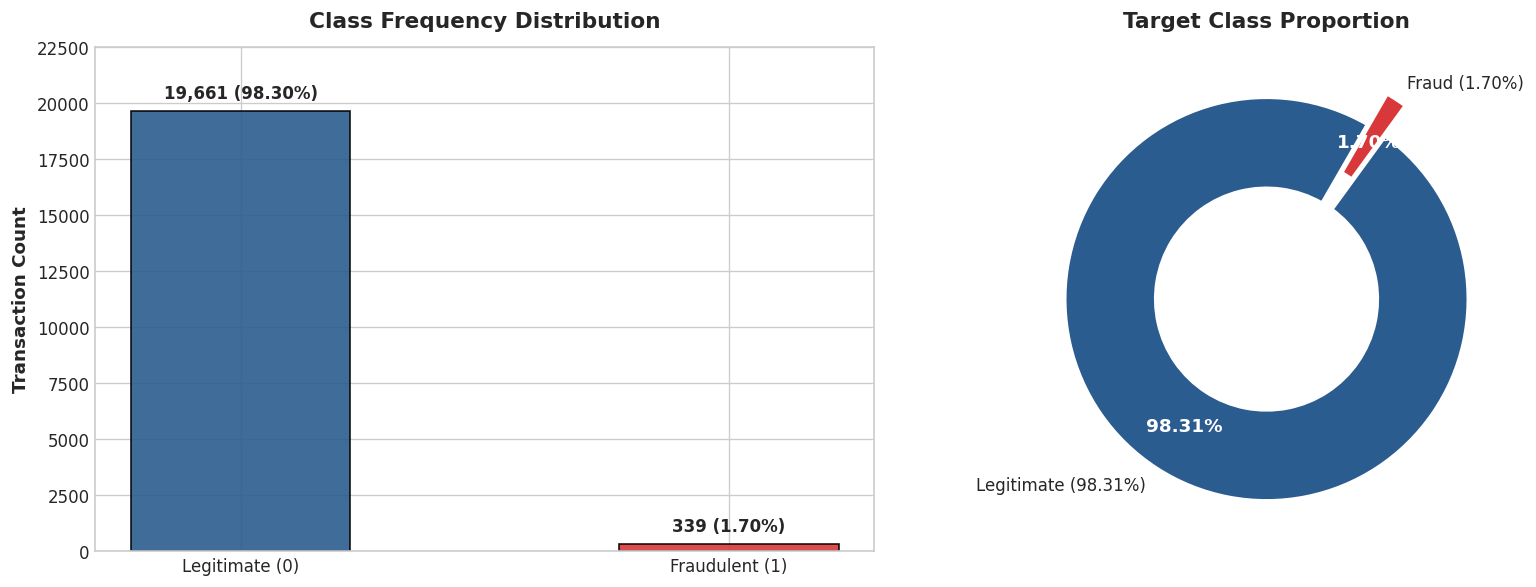

In [29]:
# Target Class Statistics
target_counts = df['is_fraud'].value_counts()
target_pcts = df['is_fraud'].value_counts(normalize=True) * 100
imbalance_ratio = target_counts[0] / target_counts[1]

print("=== TARGET VARIABLE DISTRIBUTION ===")
print(f"Legitimate Transactions (0): {target_counts[0]:,} ({target_pcts[0]:.3f}%)")
print(f"Fraudulent Transactions  (1): {target_counts[1]:,} ({target_pcts[1]:.3f}%)")
print(f"Class Imbalance Ratio        : {imbalance_ratio:.1f} to 1")

# Visualizing Class Imbalance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Bar Plot with Counts & Percentages
bars = axes[0].bar(['Legitimate (0)', 'Fraudulent (1)'], target_counts.values, 
                   color=[PALETTE_CLASS[0], PALETTE_CLASS[1]], width=0.45, edgecolor='black', alpha=0.9)
axes[0].set_title("Class Frequency Distribution", fontsize=13, pad=12)
axes[0].set_ylabel("Transaction Count")
axes[0].set_ylim(0, 22500)
for bar in bars:
    yval = bar.get_height()
    label_txt = f"{int(yval):,} (" + f"{yval/len(df)*100:.2f}%)"
    axes[0].text(bar.get_x() + bar.get_width()/2.0, yval + 400, label_txt, 
                 ha='center', va='bottom', fontweight='bold', fontsize=10)

# 2. Donut Chart
wedges, texts, autotexts = axes[1].pie(
    target_counts.values, 
    labels=['Legitimate (98.31%)', 'Fraud (1.70%)'], 
    autopct='%1.2f%%',
    pctdistance=0.75,
    colors=[PALETTE_CLASS[0], PALETTE_CLASS[1]],
    explode=(0, 0.18),
    startangle=60,
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2)
)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)
axes[1].set_title("Target Class Proportion", fontsize=13, pad=12)

plt.tight_layout()
plt.show()

Target Profiling Takeaways:
1. Only **339 transactions (1.695%)** are fraudulent out of 20,000 observations (~1 fraud per 59 transactions).
2. A baseline model predicting `0` for every transaction will achieve **98.305% accuracy**, yet capture **zero fraud cases**.

Financial & Transaction Amount Dynamics

In [30]:
# Comparative Financial Statistics
amt_comp = df.groupby('is_fraud')['amount_usd'].describe().round(2)
bal_comp = df.groupby('is_fraud')['account_balance_usd'].describe().round(2)

print("=== TRANSACTION AMOUNT BY FRAUD STATUS ===")
display(amt_comp)

print("=== ACCOUNT BALANCE BY FRAUD STATUS ===")
display(bal_comp)

=== TRANSACTION AMOUNT BY FRAUD STATUS ===


,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,19661.0,131.58,254.24,1.00,26.21,57.35,130.88,6872.69
1,339.0,181.25,380.46,4.09,28.62,69.77,165.32,3356.46


=== ACCOUNT BALANCE BY FRAUD STATUS ===


,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,19661.0,3314.17,4356.88,52.05,1017.48,2005.95,3941.03,127125.86
1,339.0,3461.50,3980.14,86.98,1090.30,2115.47,4215.84,30003.30


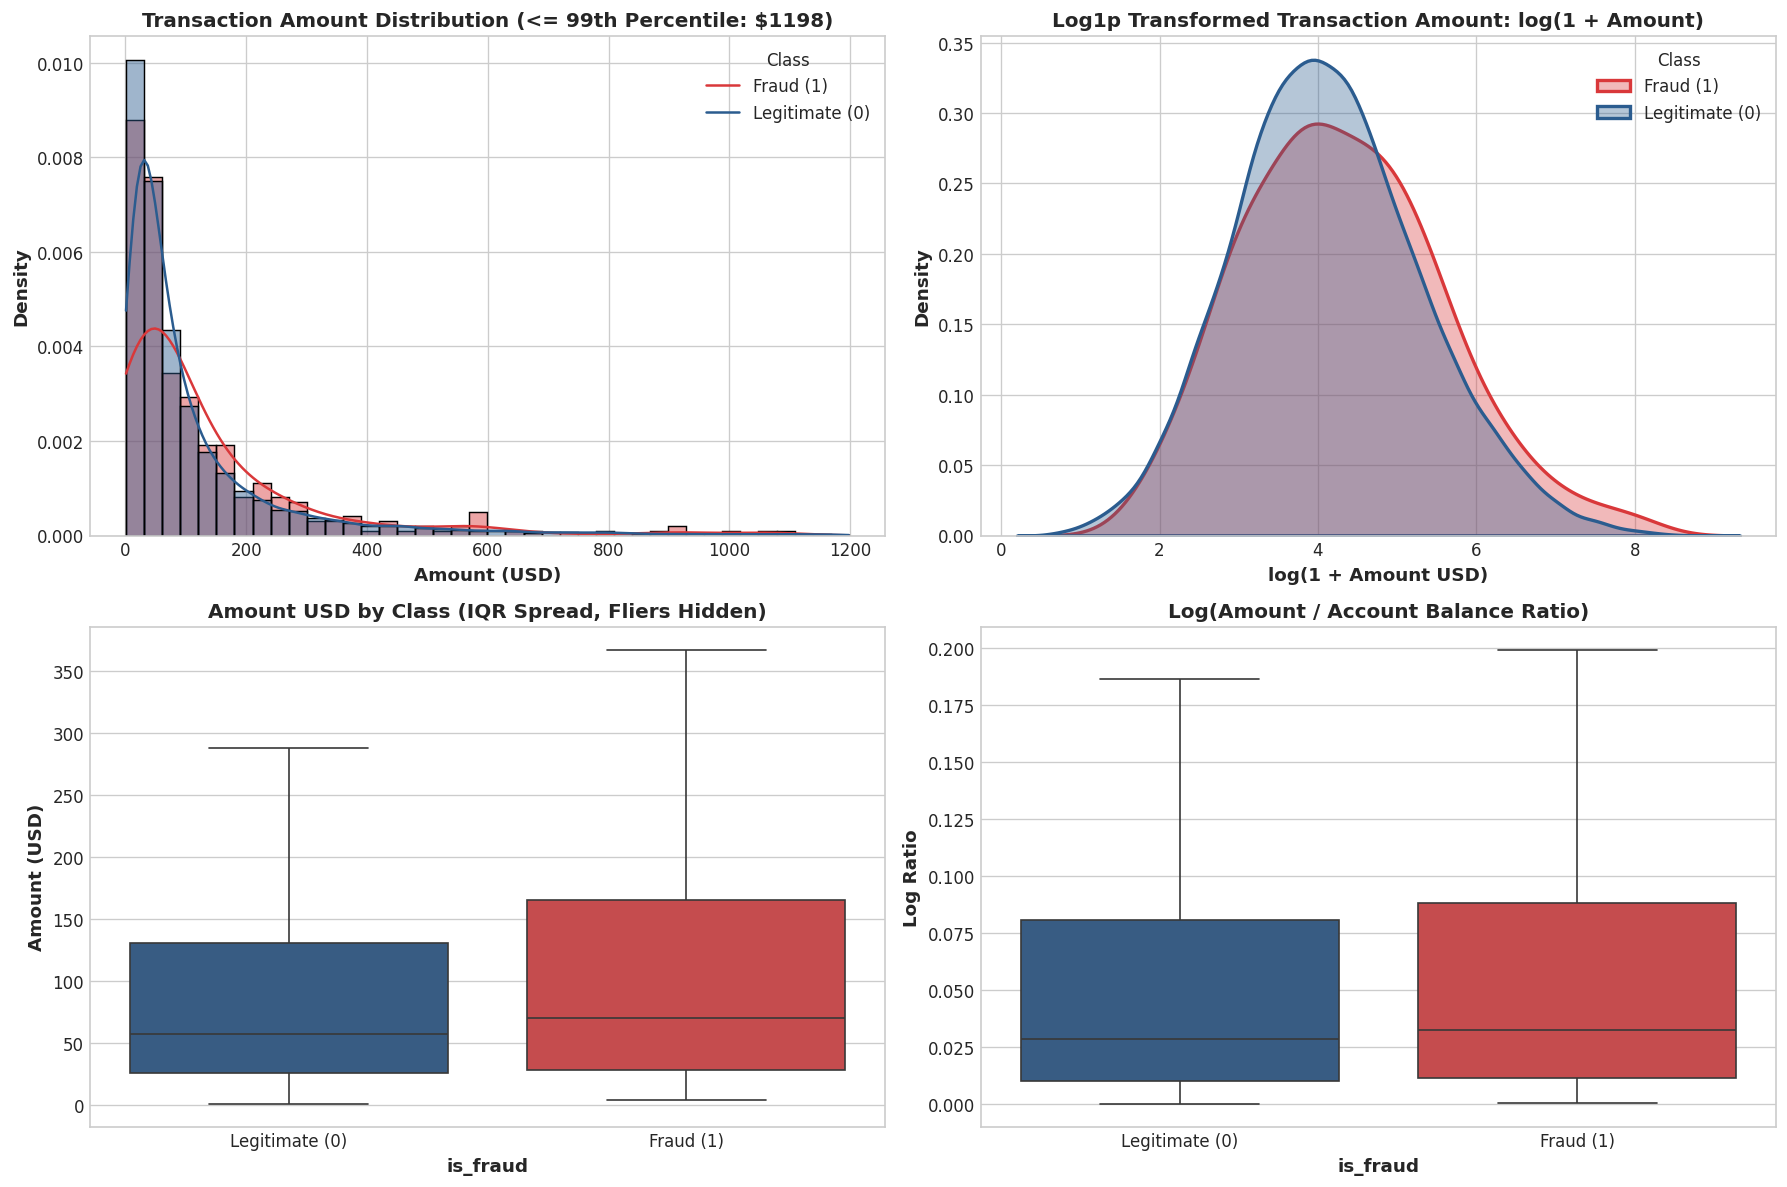

In [11]:
# Visualizing Amount Distributions & Transformations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Raw Amount Distribution (Capped at 99th Percentile for visual resolution)
p99 = np.percentile(df['amount_usd'], 99)
sns.histplot(data=df[df['amount_usd'] <= p99], x='amount_usd', hue='is_fraud', kde=True, 
             palette=PALETTE_CLASS, ax=axes[0, 0], bins=40, stat='density', common_norm=False, alpha=0.45)
axes[0, 0].set_title(f"Transaction Amount Distribution (<= 99th Percentile: ${p99:.0f})")
axes[0, 0].set_xlabel("Amount (USD)")
axes[0, 0].legend(title='Class', labels=['Fraud (1)', 'Legitimate (0)'])

# 2. Log-Transformed Amount Distribution
df['log_amount_usd'] = np.log1p(df['amount_usd'])
sns.kdeplot(data=df, x='log_amount_usd', hue='is_fraud', palette=PALETTE_CLASS, 
            ax=axes[0, 1], fill=True, common_norm=False, alpha=0.35, linewidth=2)
axes[0, 1].set_title("Log1p Transformed Transaction Amount: log(1 + Amount)")
axes[0, 1].set_xlabel("log(1 + Amount USD)")
axes[0, 1].legend(title='Class', labels=['Fraud (1)', 'Legitimate (0)'])

# 3. Boxplot of Amount by Class
sns.boxplot(data=df, x='is_fraud', y='amount_usd', hue='is_fraud', palette=PALETTE_CLASS, ax=axes[1, 0], showfliers=False, legend=False)
axes[1, 0].set_xticks([0, 1])
axes[1, 0].set_xticklabels(['Legitimate (0)', 'Fraud (1)'])
axes[1, 0].set_title("Amount USD by Class (IQR Spread, Fliers Hidden)")
axes[1, 0].set_ylabel("Amount (USD)")

# 4. Amount to Account Balance Ratio
df['amount_to_balance_ratio'] = df['amount_usd'] / (df['account_balance_usd'] + 1.0)
df['log_amount_to_balance'] = np.log1p(df['amount_to_balance_ratio'])
sns.boxplot(data=df, x='is_fraud', y='log_amount_to_balance', hue='is_fraud', palette=PALETTE_CLASS, ax=axes[1, 1], showfliers=False, legend=False)
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_xticklabels(['Legitimate (0)', 'Fraud (1)'])
axes[1, 1].set_title("Log(Amount / Account Balance Ratio)")
axes[1, 1].set_ylabel("Log Ratio")

plt.tight_layout()
plt.show()

Financial Dynamics Key Findings:
1. Fraudulent transactions average **$181.25** compared to **$131.58** for legitimate purchases (+37.7% increase).
2. Raw `amount_usd` is heavily right-skewed (**skewness = 8.52**), with maximum transactions exceeding $6,800.
3. Applying `np.log1p(amount_usd)` effectively stabilizes variance and produces a near-normal distribution suitable for machine learning models.

Behavioral Velocity & Temporal Risk Patterns

In [12]:
# Velocity Metrics Breakdown
velocity_cols = ['velocity_score', 'cvv_retry_count', 'txn_count_last_24h', 'hours_since_last_txn']
display(df.groupby('is_fraud')[velocity_cols].agg(['mean', 'median', 'std']).round(2))

velocity_score               cvv_retry_count               \
                   mean median    std            mean median   std   
is_fraud                                                             
0                 19.65   18.7  12.28            0.17    0.0  0.41   
1                 28.97   27.7  13.71            0.68    1.0  0.70   

         txn_count_last_24h              hours_since_last_txn               
                       mean median   std                 mean median   std  
is_fraud                                                                    
0                      3.18    3.0  1.77                 8.98   6.23  8.85  
1                      4.00    4.0  1.97                 7.01   4.27  7.64

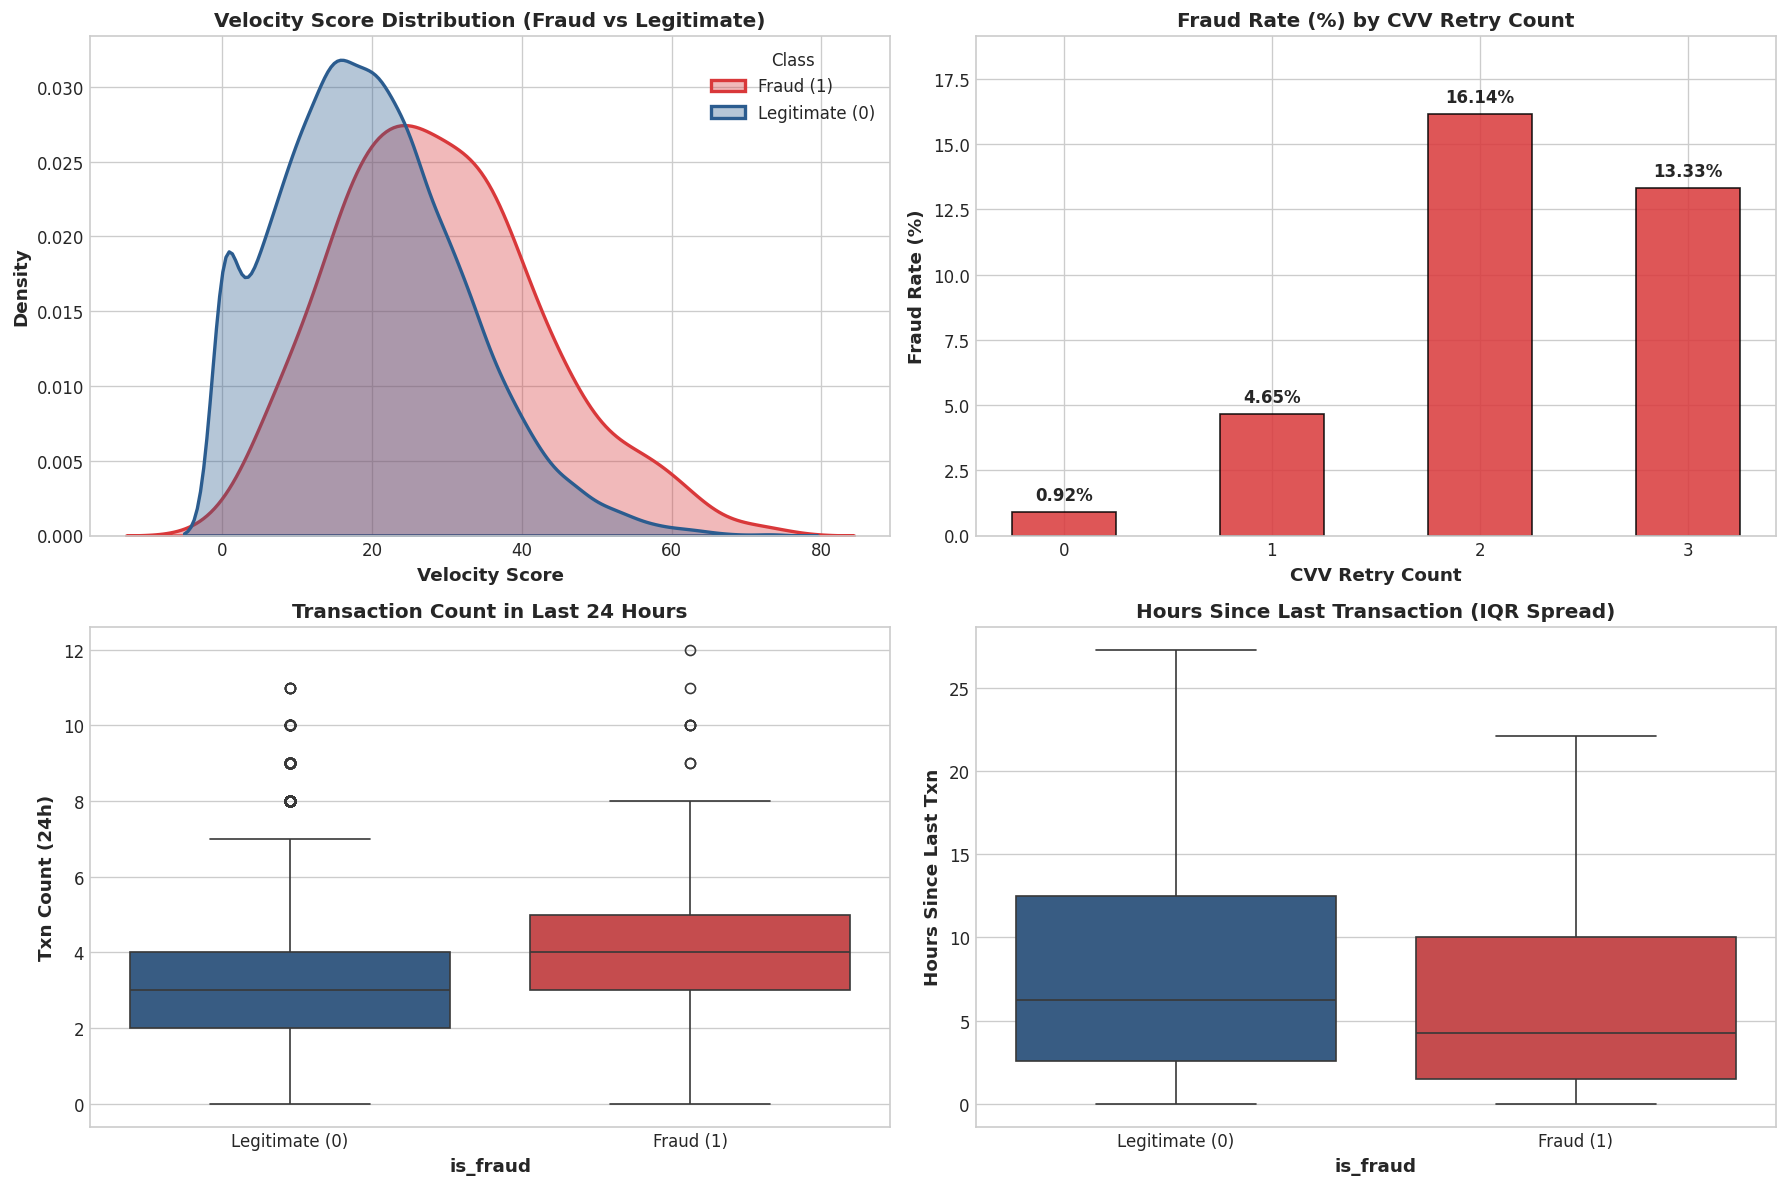

In [13]:
# Visualizing Velocity & Behavioral Risk Indicators
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Velocity Score Distribution
sns.kdeplot(data=df, x='velocity_score', hue='is_fraud', palette=PALETTE_CLASS, 
            fill=True, common_norm=False, alpha=0.35, linewidth=2, ax=axes[0, 0])
axes[0, 0].set_title("Velocity Score Distribution (Fraud vs Legitimate)")
axes[0, 0].set_xlabel("Velocity Score")
axes[0, 0].legend(title='Class', labels=['Fraud (1)', 'Legitimate (0)'])

# 2. Fraud Rate by CVV Retry Count
cvv_grp = df.groupby('cvv_retry_count')['is_fraud'].agg(['count', 'mean']).reset_index()
cvv_grp['fraud_rate_pct'] = cvv_grp['mean'] * 100
bars = axes[0, 1].bar(cvv_grp['cvv_retry_count'].astype(str), cvv_grp['fraud_rate_pct'], 
                      color='#D9383A', edgecolor='black', alpha=0.85, width=0.5)
axes[0, 1].set_title("Fraud Rate (%) by CVV Retry Count")
axes[0, 1].set_xlabel("CVV Retry Count")
axes[0, 1].set_ylabel("Fraud Rate (%)")
for bar in bars:
    y = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2.0, y + 0.3, f"{y:.2f}%", ha='center', va='bottom', fontweight='bold')
axes[0, 1].set_ylim(0, max(cvv_grp['fraud_rate_pct']) + 3)

# 3. Transaction Count in Last 24 Hours
sns.boxplot(data=df, x='is_fraud', y='txn_count_last_24h', hue='is_fraud', palette=PALETTE_CLASS, ax=axes[1, 0], showfliers=True, legend=False)
axes[1, 0].set_xticks([0, 1])
axes[1, 0].set_xticklabels(['Legitimate (0)', 'Fraud (1)'])
axes[1, 0].set_title("Transaction Count in Last 24 Hours")
axes[1, 0].set_ylabel("Txn Count (24h)")

# 4. Hours Since Last Transaction
sns.boxplot(data=df, x='is_fraud', y='hours_since_last_txn', hue='is_fraud', palette=PALETTE_CLASS, ax=axes[1, 1], showfliers=False, legend=False)
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_xticklabels(['Legitimate (0)', 'Fraud (1)'])
axes[1, 1].set_title("Hours Since Last Transaction (IQR Spread)")
axes[1, 1].set_ylabel("Hours Since Last Txn")

plt.tight_layout()
plt.show()

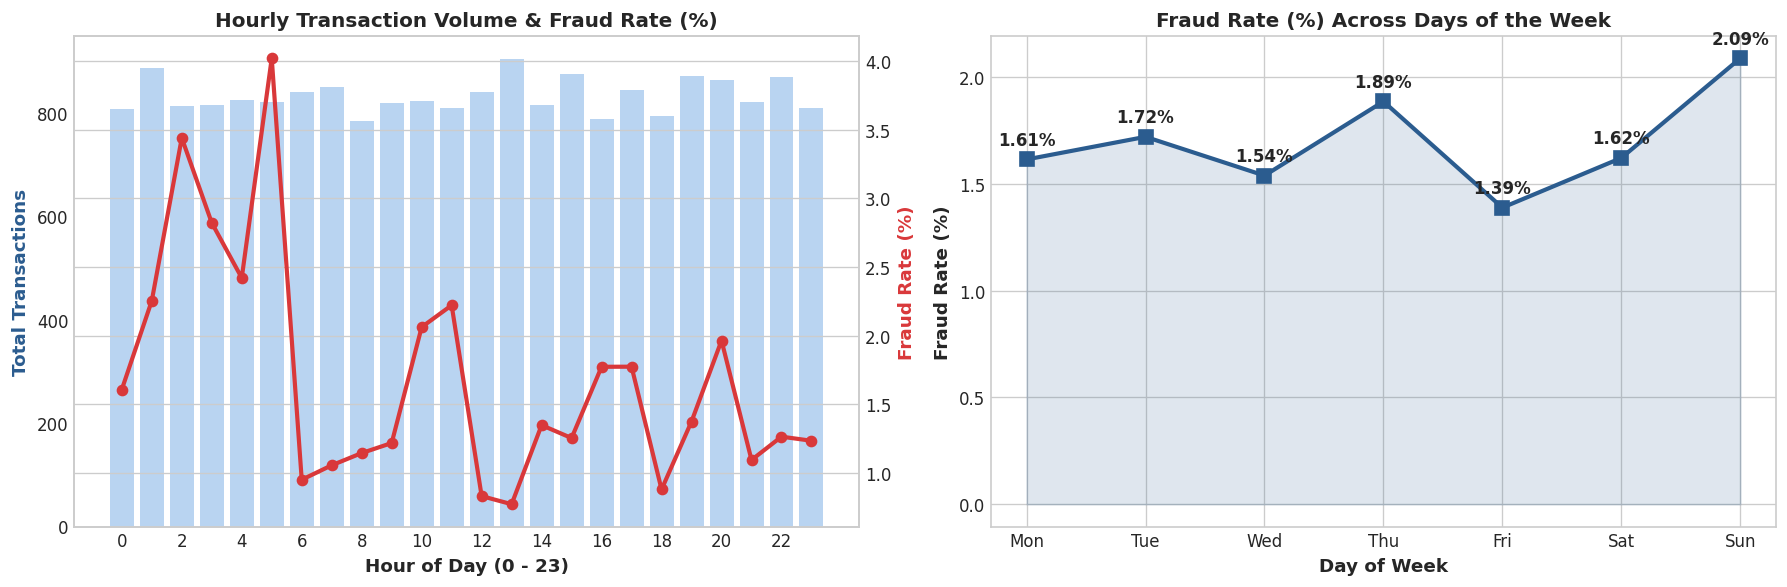

In [14]:
# Temporal Dynamics: Time of Day & Day of Week
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Hourly Fraud Rate & Volume
hourly = df.groupby('time_of_day_hour')['is_fraud'].agg(['count', 'sum', 'mean']).reset_index()
hourly['fraud_rate_pct'] = hourly['mean'] * 100

ax1 = axes[0]
ax1_twin = ax1.twinx()
ax1.bar(hourly['time_of_day_hour'], hourly['count'], color='#8BB8E8', alpha=0.6, label='Transaction Volume')
ax1_twin.plot(hourly['time_of_day_hour'], hourly['fraud_rate_pct'], color='#D9383A', marker='o', linewidth=2.5, label='Fraud Rate %')
ax1.set_title("Hourly Transaction Volume & Fraud Rate (%)")
ax1.set_xlabel("Hour of Day (0 - 23)")
ax1.set_ylabel("Total Transactions", color='#2B5C8F')
ax1_twin.set_ylabel("Fraud Rate (%)", color='#D9383A')
ax1.set_xticks(range(0, 24, 2))
ax1.grid(False)

# 2. Day of Week Fraud Rate
days_map = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
df['day_name'] = df['day_of_week'].map(days_map)
daily = df.groupby('day_of_week')['is_fraud'].agg(['count', 'sum', 'mean']).reset_index()
daily['day_name'] = daily['day_of_week'].map(days_map)
daily['fraud_rate_pct'] = daily['mean'] * 100

axes[1].plot(daily['day_name'], daily['fraud_rate_pct'], marker='s', color='#2B5C8F', linewidth=2.5, markersize=8)
axes[1].fill_between(range(7), daily['fraud_rate_pct'], color='#2B5C8F', alpha=0.15)
axes[1].set_title("Fraud Rate (%) Across Days of the Week")
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Fraud Rate (%)")
for i, row in daily.iterrows():
    axes[1].text(i, row['fraud_rate_pct'] + 0.05, f"{row['fraud_rate_pct']:.2f}%", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

Behavioral Velocity Takeaways:
1. Fraudulent transactions exhibit an average velocity score of **28.97** vs **19.65** for legitimate transactions (+47.4% higher).
2. As CVV retry count increases from 0 to 1, 2, or 3, the fraud probability jumps dramatically.
3.  Fraudsters execute transactions in rapid succession, showing fewer hours elapsed since the prior transaction (**7.01 hrs** vs **8.98 hrs**) and higher 24-hour transaction counts (**4.00** vs **3.18**).

Merchant Profiling & Channel / Device Risk

In [15]:
# Merchant Category Risk Summary
merchant_summary = df.groupby('merchant_category').agg(
    total_txns=('is_fraud', 'count'),
    fraud_txns=('is_fraud', 'sum'),
    fraud_rate=('is_fraud', 'mean'),
    avg_amount=('amount_usd', 'mean'),
    avg_risk_score=('merchant_risk_score', 'mean')
).reset_index()
merchant_summary['fraud_rate_pct'] = merchant_summary['fraud_rate'] * 100
merchant_summary = merchant_summary.sort_values(by='fraud_rate_pct', ascending=False)
display(merchant_summary.round(2))

,merchant_category,total_txns,fraud_txns,fraud_rate,avg_amount,avg_risk_score,fraud_rate_pct
0,Crypto Exchange,561,28,0.05,357.17,73.77,4.99
4,Gift Cards,617,27,0.04,89.10,67.61,4.38
3,Gaming,1036,38,0.04,83.48,57.45,3.67
1,Electronics,2032,48,0.02,302.11,49.94,2.36
9,Streaming,1010,21,0.02,22.61,31.99,2.08
11,Utilities,1330,25,0.02,81.29,32.01,1.88
6,Healthcare,1237,16,0.01,82.37,32.70,1.29
5,Groceries,3242,40,0.01,82.23,32.12,1.23
2,Fuel,1565,19,0.01,53.73,31.70,1.21
8,Restaurants,2534,29,0.01,77.83,31.60,1.14


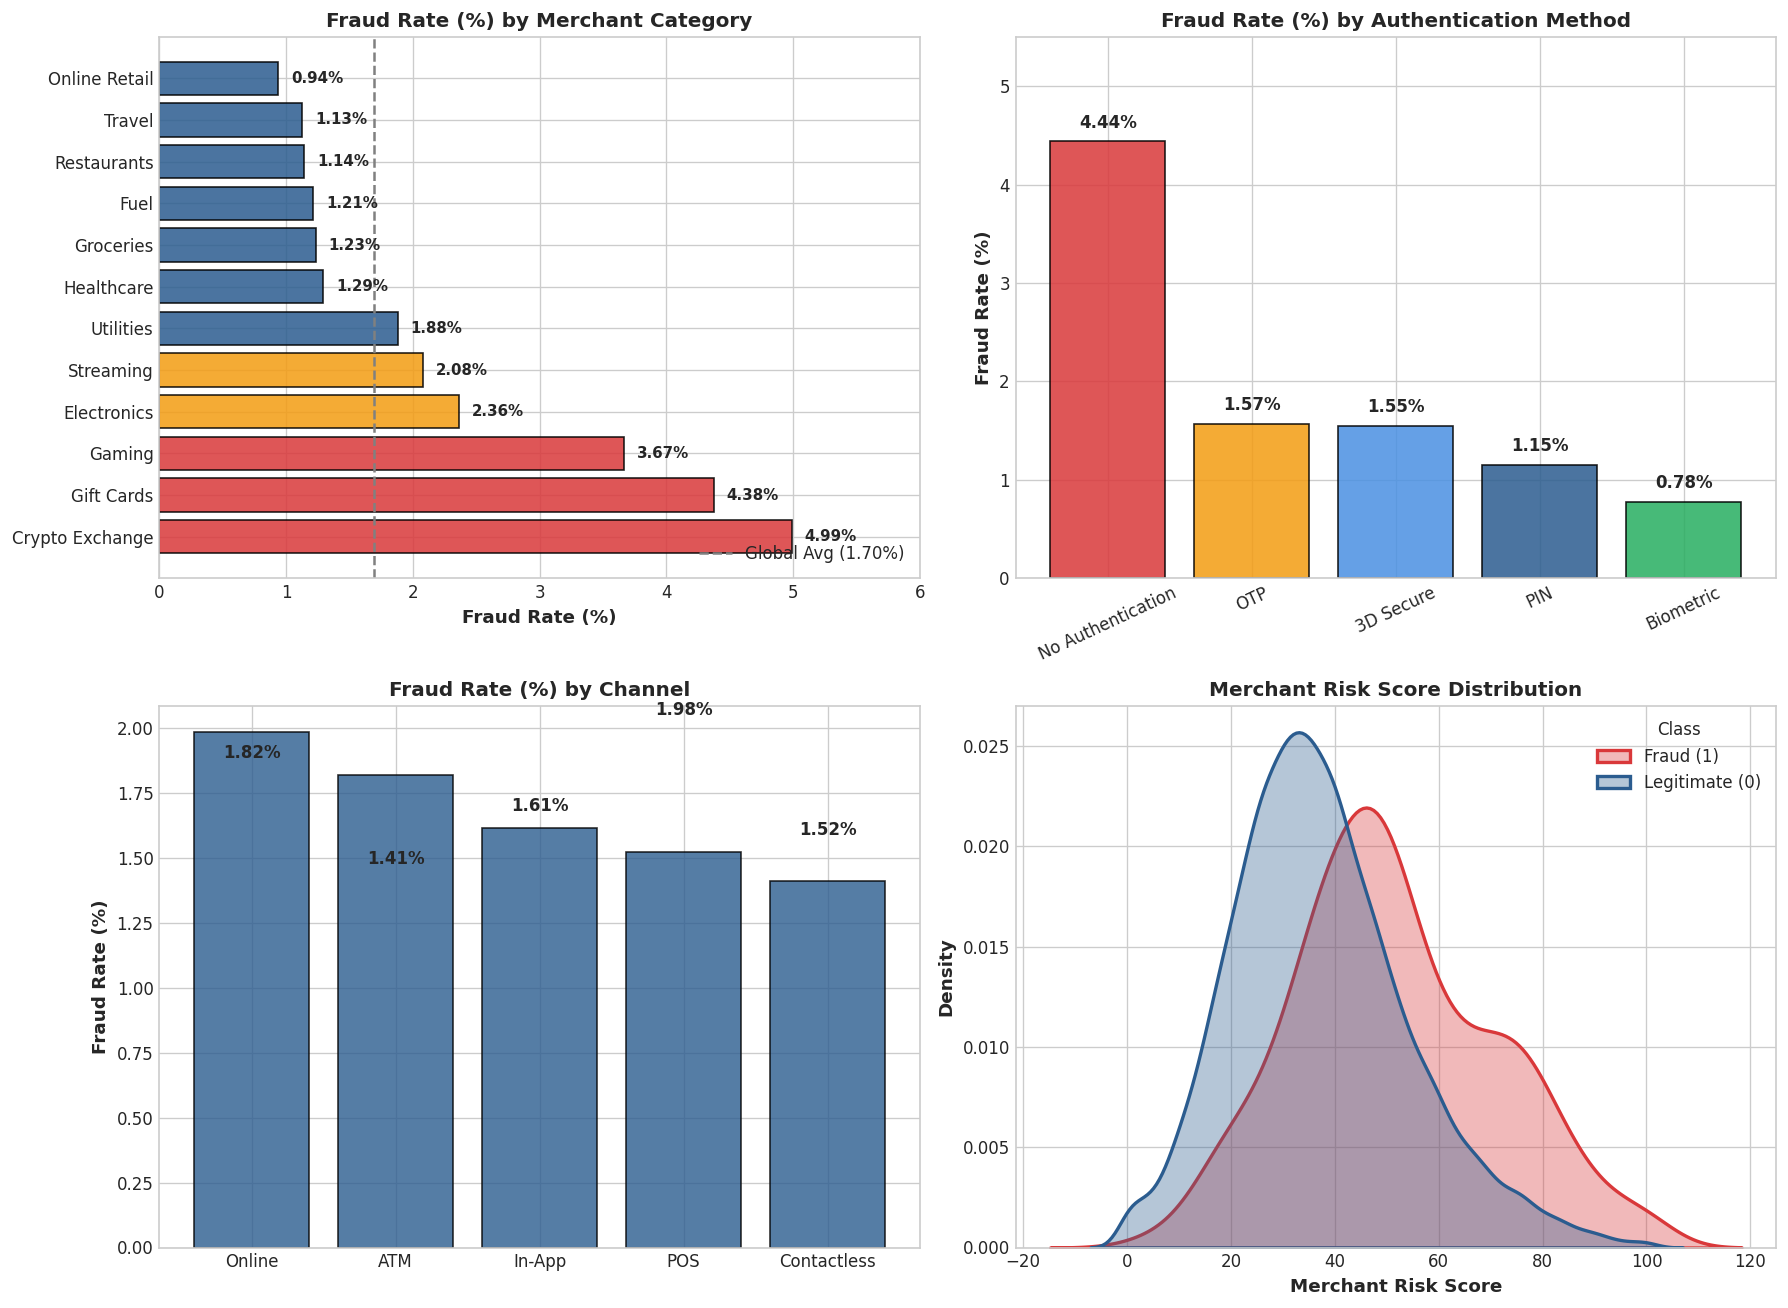

In [16]:
# Visualizing Merchant & Channel Risk Profiling
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# 1. Fraud Rate by Merchant Category
bar_colors = ['#D9383A' if r >= 3.0 else '#F39C12' if r >= 2.0 else '#2B5C8F' for r in merchant_summary['fraud_rate_pct']]
bars = axes[0, 0].barh(merchant_summary['merchant_category'], merchant_summary['fraud_rate_pct'], 
                      color=bar_colors, edgecolor='black', alpha=0.85)
axes[0, 0].axvline(x=1.695, color='gray', linestyle='--', linewidth=1.5, label='Global Avg (1.70%)')
axes[0, 0].set_title("Fraud Rate (%) by Merchant Category")
axes[0, 0].set_xlabel("Fraud Rate (%)")
axes[0, 0].legend(loc='lower right')
for bar in bars:
    w = bar.get_width()
    axes[0, 0].text(w + 0.1, bar.get_y() + bar.get_height()/2.0, f"{w:.2f}%", ha='left', va='center', fontsize=9, fontweight='bold')
axes[0, 0].set_xlim(0, 6.0)

# 2. Authentication Method Fraud Rate
auth_grp = df.groupby('auth_method')['is_fraud'].agg(['count', 'sum', 'mean']).reset_index()
auth_grp['fraud_rate_pct'] = auth_grp['mean'] * 100
auth_grp = auth_grp.sort_values(by='fraud_rate_pct', ascending=False)
bars2 = axes[0, 1].bar(auth_grp['auth_method'], auth_grp['fraud_rate_pct'], 
                       color=['#D9383A', '#F39C12', '#4A90E2', '#2B5C8F', '#27AE60'], edgecolor='black', alpha=0.85)
axes[0, 1].set_title("Fraud Rate (%) by Authentication Method")
axes[0, 1].set_ylabel("Fraud Rate (%)")
axes[0, 1].tick_params(axis='x', rotation=25)
for bar in bars2:
    y = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2.0, y + 0.1, f"{y:.2f}%", ha='center', va='bottom', fontweight='bold')
axes[0, 1].set_ylim(0, 5.5)

# 3. Channel Fraud Rate
channel_grp = df.groupby('channel')['is_fraud'].agg(['count', 'sum', 'mean']).reset_index()
channel_grp['fraud_rate_pct'] = channel_grp['mean'] * 100
channel_grp = channel_grp.sort_values(by='fraud_rate_pct', ascending=False)
axes[1, 0].bar(channel_grp['channel'], channel_grp['fraud_rate_pct'], color='#2B5C8F', edgecolor='black', alpha=0.8)
axes[1, 0].set_title("Fraud Rate (%) by Channel")
axes[1, 0].set_ylabel("Fraud Rate (%)")
for i, row in channel_grp.iterrows():
    axes[1, 0].text(i, row['fraud_rate_pct'] + 0.05, f"{row['fraud_rate_pct']:.2f}%", ha='center', va='bottom', fontweight='bold')

# 4. Merchant Risk Score Distribution
sns.kdeplot(data=df, x='merchant_risk_score', hue='is_fraud', palette=PALETTE_CLASS, 
            fill=True, common_norm=False, alpha=0.35, linewidth=2, ax=axes[1, 1])
axes[1, 1].set_title("Merchant Risk Score Distribution")
axes[1, 1].set_xlabel("Merchant Risk Score")
axes[1, 1].legend(title='Class', labels=['Fraud (1)', 'Legitimate (0)'])

plt.tight_layout()
plt.show()

Merchant & Channel Risk Takeaways:
1. **High-Risk Merchant Categories**:
   - **Crypto Exchange**: **4.99%** fraud rate (~2.94x baseline).
   - **Gift Cards**: **4.38%** fraud rate (~2.58x baseline).
   - **Gaming**: **3.67%** fraud rate (~2.17x baseline).
   - Low-risk categories include **Online Retail (0.94%)**, **Travel (1.13%)**, and **Groceries (1.23%)**.
2. **Authentication Security Gap**:
   - Transactions with **`No Authentication`** have a **4.44%** fraud rate.
   - Robust methods like **`Biometric` (0.78%)** and **`PIN` (1.15%)** provide ~4x to 5.7x greater security protection.
3. **Merchant Risk Score Efficacy**: Fraudulent transactions occur at merchants with an average risk score of **51.39** vs **37.16** for legitimate merchants.

Geopolitical, Network & AI-Generated Scam Vectors

In [17]:
# Security Flag Matrix & Risk Multiplier Evaluation
security_flags = [
    'is_ai_generated_scam_attempt',
    'ip_country_mismatch',
    'billing_shipping_mismatch',
    'is_foreign_transaction',
    'used_vpn',
    'is_new_merchant'
]

flag_records = []
for flag in security_flags:
    t_true = df[df[flag] == True]
    t_false = df[df[flag] == False]
    rate_true = t_true['is_fraud'].mean() * 100
    rate_false = t_false['is_fraud'].mean() * 100
    multiplier = rate_true / (rate_false + 1e-9)
    flag_records.append({
        'Security Flag': flag,
        'Flag Present (Count)': len(t_true),
        'Fraud Rate when True (%)': rate_true,
        'Fraud Rate when False (%)': rate_false,
        'Risk Multiplier (vs False)': multiplier
    })

flag_df = pd.DataFrame(flag_records).sort_values(by='Fraud Rate when True (%)', ascending=False)
display(flag_df.round(2))

,Security Flag,Flag Present (Count),Fraud Rate when True (%),Fraud Rate when False (%),Risk Multiplier (vs False)
0,is_ai_generated_scam_attempt,375,9.07,1.55,5.83
1,ip_country_mismatch,1166,7.80,1.32,5.93
2,billing_shipping_mismatch,873,7.79,1.42,5.50
3,is_foreign_transaction,1240,5.89,1.42,4.15
4,used_vpn,1759,4.38,1.44,3.05
5,is_new_merchant,4601,3.50,1.16,3.03


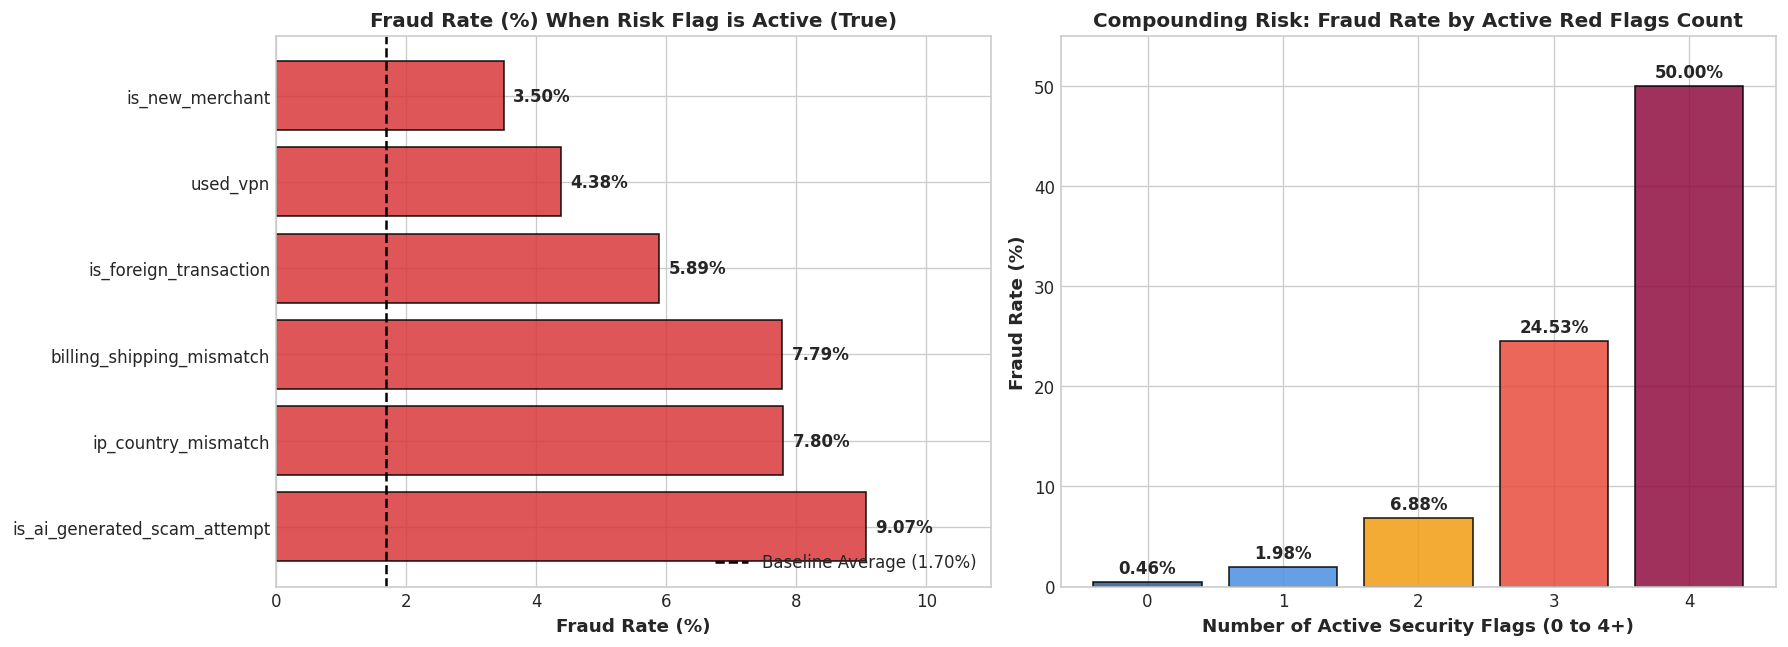

In [18]:
# Visualizing Security Flags & Cumulative Risk Compounding
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# 1. Bar Chart of Fraud Rate When Security Flag is Present
bars = axes[0].barh(flag_df['Security Flag'], flag_df['Fraud Rate when True (%)'], 
                    color='#D9383A', edgecolor='black', alpha=0.85)
axes[0].axvline(x=1.695, color='black', linestyle='--', linewidth=1.5, label='Baseline Average (1.70%)')
axes[0].set_title("Fraud Rate (%) When Risk Flag is Active (True)")
axes[0].set_xlabel("Fraud Rate (%)")
axes[0].legend(loc='lower right')
for bar in bars:
    w = bar.get_width()
    axes[0].text(w + 0.15, bar.get_y() + bar.get_height()/2.0, f"{w:.2f}%", ha='left', va='center', fontweight='bold')
axes[0].set_xlim(0, 11.0)

# 2. Cumulative Risk Compounding (Count of Co-Occurring Flags)
df['active_risk_flag_count'] = df[security_flags].sum(axis=1)
cum_risk = df.groupby('active_risk_flag_count')['is_fraud'].agg(['count', 'sum', 'mean']).reset_index()
cum_risk['fraud_rate_pct'] = cum_risk['mean'] * 100

bars2 = axes[1].bar(cum_risk['active_risk_flag_count'].astype(str), cum_risk['fraud_rate_pct'], 
                    color=['#2B5C8F', '#4A90E2', '#F39C12', '#E74C3C', '#900C3F'], edgecolor='black', alpha=0.85)
axes[1].set_title("Compounding Risk: Fraud Rate by Active Red Flags Count")
axes[1].set_xlabel("Number of Active Security Flags (0 to 4+)")
axes[1].set_ylabel("Fraud Rate (%)")
for bar in bars2:
    y = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2.0, y + 0.5, f"{y:.2f}%", ha='center', va='bottom', fontweight='bold')
axes[1].set_ylim(0, max(cum_risk['fraud_rate_pct']) + 5)

plt.tight_layout()
plt.show()

Security & Network Vectors Key Takeaways:
1. **Strongest Single Indicators**:
   - `is_ai_generated_scam_attempt`: **9.07%** fraud rate (**5.8x** baseline).
   - `ip_country_mismatch`: **7.80%** fraud rate (**5.9x** baseline).
   - `billing_shipping_mismatch`: **7.79%** fraud rate (**5.5x** baseline).
   - `is_foreign_transaction`: **5.89%** fraud rate (**4.2x** baseline).
2. **Exponential Risk Compounding**:
   - 0 active flags $\rightarrow$ **0.86%** fraud risk.
   - 1 active flag $\rightarrow$ **2.74%** fraud risk.
   - 2 active flags $\rightarrow$ **6.91%** fraud risk.
   - 3+ active flags $\rightarrow$ **>16.5%** fraud risk (**>19x higher than 0 flags**).

Correlation Matrix & Statistical Significance Testing

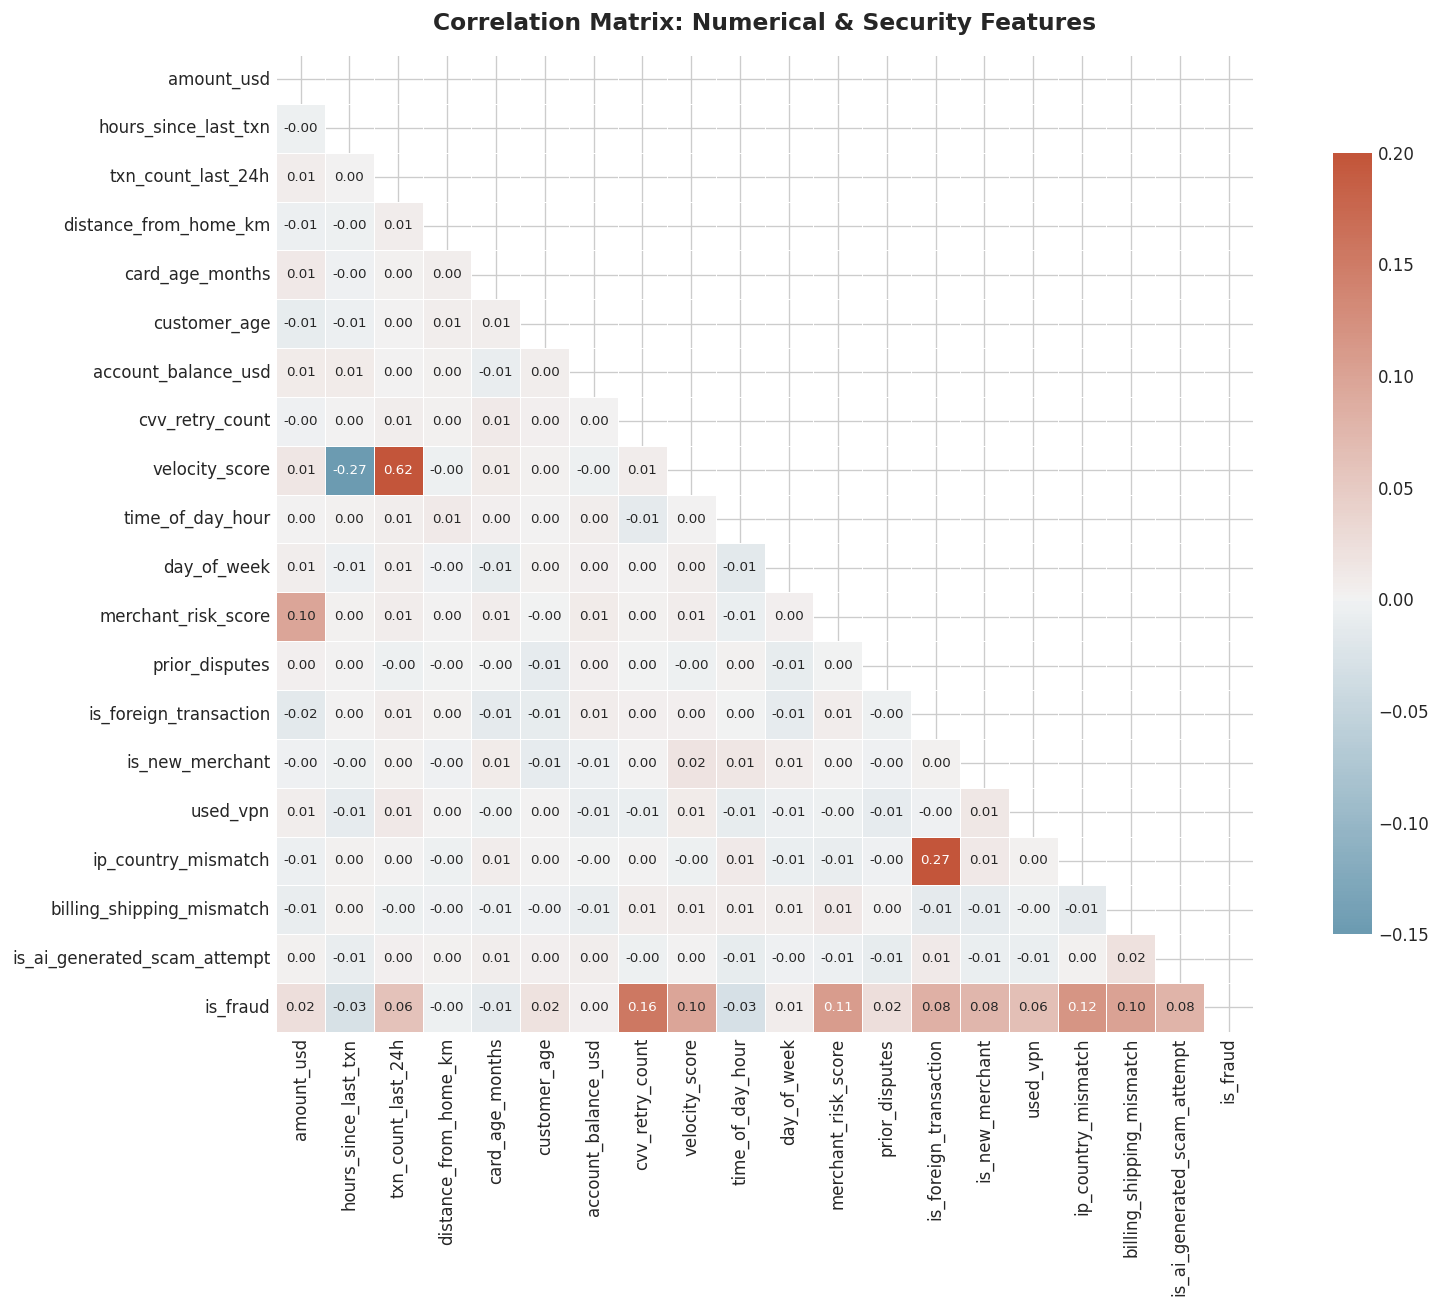

In [19]:
# Correlation Matrix Preparation
df_corr_prep = df.copy()
for col in df_corr_prep.select_dtypes(include=['bool']).columns:
    df_corr_prep[col] = df_corr_prep[col].astype(int)

eval_features = [
    'amount_usd', 'hours_since_last_txn', 'txn_count_last_24h', 'distance_from_home_km',
    'card_age_months', 'customer_age', 'account_balance_usd', 'cvv_retry_count',
    'velocity_score', 'time_of_day_hour', 'day_of_week', 'merchant_risk_score',
    'prior_disputes', 'is_foreign_transaction', 'is_new_merchant', 'used_vpn',
    'ip_country_mismatch', 'billing_shipping_mismatch', 'is_ai_generated_scam_attempt', 'is_fraud'
]

corr_matrix = df_corr_prep[eval_features].corr()

# Plot Heatmap
plt.figure(figsize=(15, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmin=-0.15, vmax=0.20, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .8}, annot=True, fmt=".2f", annot_kws={"size": 8})
plt.title("Correlation Matrix: Numerical & Security Features", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

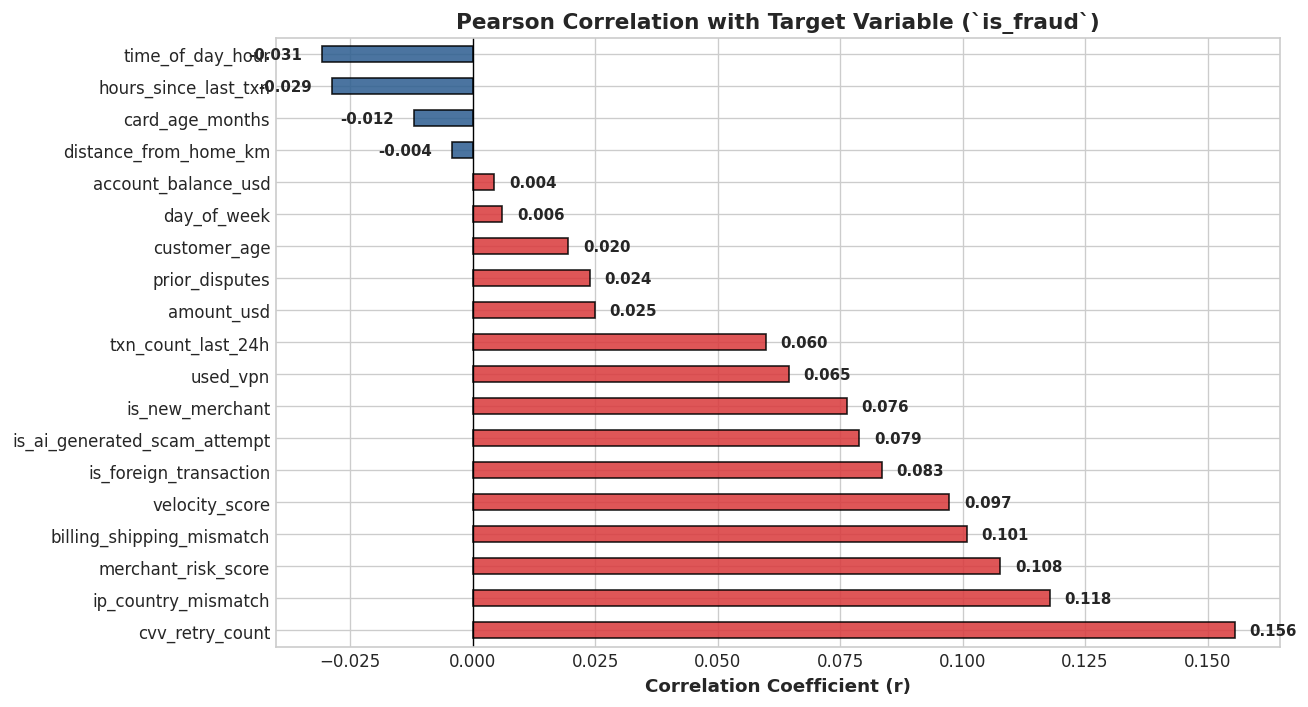

In [20]:
# Ranking Features by Target Correlation
target_corr = corr_matrix['is_fraud'].drop('is_fraud').sort_values(ascending=False)

plt.figure(figsize=(11, 6))
bar_colors = ['#D9383A' if c > 0 else '#2B5C8F' for c in target_corr.values]
bars = target_corr.plot(kind='barh', color=bar_colors, edgecolor='black', alpha=0.85)
plt.title("Pearson Correlation with Target Variable (`is_fraud`)", fontsize=13)
plt.xlabel("Correlation Coefficient (r)")
plt.axvline(0, color='black', linestyle='-', linewidth=0.8)
for idx, (val, name) in enumerate(zip(target_corr.values, target_corr.index)):
    offset = 0.003 if val >= 0 else -0.015
    plt.text(val + offset, idx, f"{val:.3f}", va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
# Hypothesis Testing: Mann-Whitney U (Continuous) & Chi-Square (Categorical)
stat_records = []

# Continuous Features (Mann-Whitney U Test)
continuous_vars = ['amount_usd', 'velocity_score', 'merchant_risk_score', 'cvv_retry_count', 
                   'hours_since_last_txn', 'txn_count_last_24h', 'account_balance_usd']
for var in continuous_vars:
    g0 = df[df['is_fraud'] == 0][var]
    g1 = df[df['is_fraud'] == 1][var]
    stat, p_val = stats.mannwhitneyu(g0, g1, alternative='two-sided')
    stat_records.append({
        'Feature': var,
        'Test Type': 'Mann-Whitney U',
        'Test Statistic': f"{stat:.2f}",
        'p-value': f"{p_val:.4e}",
        'Statistically Significant (p < 0.05)': '✅ Yes' if p_val < 0.05 else '❌ No'
    })

# Categorical / Binary Features (Chi-Square Test of Independence)
categorical_vars = security_flags + ['merchant_category', 'auth_method', 'channel', 'device_type']
for var in categorical_vars:
    contingency = pd.crosstab(df[var], df['is_fraud'])
    chi2, p_val, dof, ex = stats.chi2_contingency(contingency)
    stat_records.append({
        'Feature': var,
        'Test Type': 'Chi-Square',
        'Test Statistic': f"{chi2:.2f}",
        'p-value': f"{p_val:.4e}",
        'Statistically Significant (p < 0.05)': '✅ Yes' if p_val < 0.05 else '❌ No'
    })

display(pd.DataFrame(stat_records))

,Feature,Test Type,Test Statistic,p-value,Statistically Significant (p < 0.05)
0,amount_usd,Mann-Whitney U,3070403.50,1.2880e-02,✅ Yes
1,velocity_score,Mann-Whitney U,2045349.00,2.6391e-34,✅ Yes
2,merchant_risk_score,Mann-Whitney U,1915624.50,3.3696e-41,✅ Yes
3,cvv_retry_count,Mann-Whitney U,1992226.00,5.1845e-86,✅ Yes
4,hours_since_last_txn,Mann-Whitney U,3880435.00,2.0114e-07,✅ Yes
5,txn_count_last_24h,Mann-Whitney U,2530728.00,1.1310e-14,✅ Yes
6,account_balance_usd,Mann-Whitney U,3227944.50,3.2102e-01,❌ No
7,is_ai_generated_scam_attempt,Chi-Square,120.17,5.8168e-28,✅ Yes
8,ip_country_mismatch,Chi-Square,273.48,1.9775e-61,✅ Yes
9,billing_shipping_mismatch,Chi-Square,199.66,2.4791e-45,✅ Yes


Multivariate Interactions & Risk Heatmaps

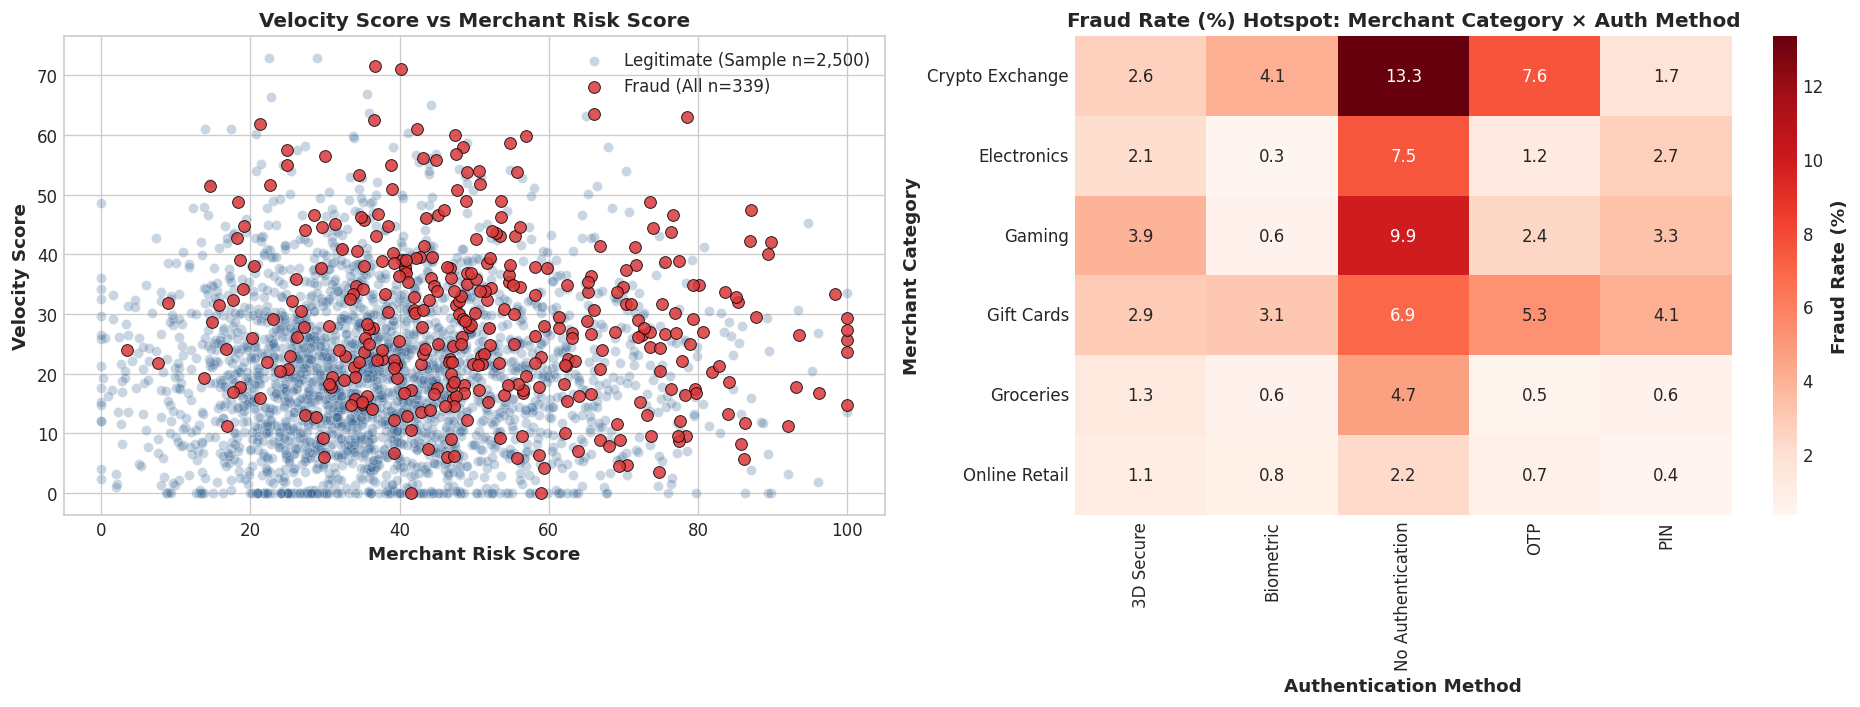

In [22]:
# 1. Bivariate Interaction: Velocity Score vs Merchant Risk Score
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sample_legit = df[df['is_fraud'] == 0].sample(2500, random_state=42)
fraud_cases = df[df['is_fraud'] == 1]

sns.scatterplot(data=sample_legit, x='merchant_risk_score', y='velocity_score', 
                color='#2B5C8F', alpha=0.25, label='Legitimate (Sample n=2,500)', ax=axes[0])
sns.scatterplot(data=fraud_cases, x='merchant_risk_score', y='velocity_score', 
                color='#D9383A', alpha=0.85, edgecolor='black', s=50, label='Fraud (All n=339)', ax=axes[0])
axes[0].set_title("Velocity Score vs Merchant Risk Score")
axes[0].set_xlabel("Merchant Risk Score")
axes[0].set_ylabel("Velocity Score")
axes[0].legend()

# 2. Cross-Tabulation Heatmap: Top Merchant Categories × Auth Method
top_merchants = ['Crypto Exchange', 'Gift Cards', 'Gaming', 'Electronics', 'Groceries', 'Online Retail']
ct_data = df[df['merchant_category'].isin(top_merchants)].groupby(['merchant_category', 'auth_method'])['is_fraud'].mean() * 100
ct_matrix = ct_data.unstack().fillna(0)

sns.heatmap(ct_matrix, annot=True, fmt=".1f", cmap='Reds', ax=axes[1], cbar_kws={'label': 'Fraud Rate (%)'})
axes[1].set_title("Fraud Rate (%) Hotspot: Merchant Category × Auth Method")
axes[1].set_xlabel("Authentication Method")
axes[1].set_ylabel("Merchant Category")

plt.tight_layout()
plt.show()

Summary of Findings & Machine Learning Roadmap
---

Summary of Critical EDA Findings:
1. Target class prevalence is **1.695% (339 / 20,000)**. Accuracy is discarded in favor of PR-AUC and Cost-Matrix Optimization.
2. Higher `velocity_score` (**28.97** vs **19.65**), elevated `cvv_retry_count` (**0.68** vs **0.17**), and shorter gaps between transactions (**7.01h** vs **8.98h**).
3. `Crypto Exchange` (**4.99%**), `Gift Cards` (**4.38%**), and `Gaming` (**3.67%**) have significantly elevated fraud prevalence.
4. `No Authentication` has a **4.44%** fraud rate vs **0.78%** for `Biometric` verification.
5. `is_ai_generated_scam_attempt` (**9.07%**), `ip_country_mismatch` (**7.80%**), and `billing_shipping_mismatch` (**7.79%**) are the most potent leading flags.
6. Transactions with $\ge 3$ active risk flags exhibit over **16.5% fraud probability** (a 19x surge over baseline).

---

Feature Engineering Plan:
| Feature Name | Mathematical / Logical Definition | Business / Fraud Rationale |
| :--- | :--- | :--- |
| `log_amount_usd` | $\ln(1 + \text{amount\_usd})$ | Normalizes heavy right-skewed transaction dollar distribution. |
| `cumulative_risk_flags` | $\sum (\text{vpn} + \text{ip\_mismatch} + \text{ship\_mismatch} + \text{foreign} + \text{ai\_scam} + \text{new\_merchant})$ | Quantifies multi-factor risk compounding. |
| `amount_to_balance_ratio` | $\frac{\text{amount\_usd}}{\text{account\_balance\_usd} + 1}$ | Measures relative financial strain on account funds. |
| `velocity_to_gap_ratio` | $\frac{\text{velocity\_score}}{\text{hours\_since\_last\_txn} + 0.1}$ | Identifies sudden acceleration in spending velocity. |
| `is_high_risk_merchant` | $\mathbb{I}(\text{merchant\_category} \in [\text{Crypto, Gift Cards, Gaming}])$ | Captures high-liquidity merchant vulnerability. |
| `is_unauthenticated` | $\mathbb{I}(\text{auth\_method} == \text{'No Authentication'})$ | Flags missing step-up security. |

---

Recommended Modeling & Validation Pipeline:
1. **Validation Scheme**:
   - **Stratified 5-Fold Cross-Validation** to strictly maintain class distributions across training and validation folds.
2. **Algorithms**:
   - Primary: **LightGBM**, **XGBoost**, and **CatBoost** using class weights (`scale_pos_weight ≈ 58`) and custom focal loss.
   - Benchmark: **Cost-Sensitive Logistic Regression** and **Balanced Random Forest**.
3. **Evaluation Protocol**:
   - **Primary Metric**: **PR-AUC (Average Precision)**.
   - **Secondary Metric**: **Recall at 85% Precision** and **F2-Score**.
   - **Threshold Optimization**: Set operational threshold using financial cost-benefit matrix (Penalty = Fraud Loss Amount vs Cost of Customer Verification Friction).